In [1]:
%load_ext autoreload
%autoreload 2

import logging
import math
import os
from tqdm import tqdm

from ema_pytorch import EMA
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LogNorm 
import numpy as np
import torch
import zuko

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')


In [2]:
sample_dir = "sample/2d_nf"
model_dir = "models/2d_nf"
fig_dir = "figs/2d_nf"

os.makedirs(sample_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)
os.makedirs(fig_dir, exist_ok=True)

## Target distribution

In [3]:
def eight_normal_sample(n, dim=2, scale=5, var=0.3):
    m = torch.distributions.multivariate_normal.MultivariateNormal(
        torch.zeros(dim), var * torch.eye(dim)
    )
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    noise = m.sample((n,))
    multi = torch.multinomial(torch.ones(8), n, replacement=True)
    data = []
    for i in range(n):
        data.append(centers[multi[i]] + noise[i])
    data = torch.stack(data)
    return data.to(torch.float32)
    
def eight_normal_log_prob(x, dim=2, scale=5, var=0.3):
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    
    # Compute per-component densities
    sigma2 = var
    normalization = -0.5 * dim * torch.log(2 * torch.tensor(np.pi) * sigma2)
    log_probs = []
    for center in centers:
        log_prob = normalization - torch.sum((x - center) ** 2, dim=-1) / (2 * sigma2)
        log_probs.append(log_prob)
    log_probs = torch.stack(log_probs, dim=-1)
    # Log-sum-exp trick for numerical stability
    max_log_prob, _ = torch.max(log_probs, dim=-1, keepdim=True)
    mixture_log_prob = max_log_prob + torch.log(torch.sum(torch.exp(log_probs - max_log_prob), dim=-1, keepdim=True)) - torch.log(torch.tensor(len(centers))).squeeze()
    return mixture_log_prob.flatten()

## Plotting utils

In [4]:
# Define limits for consistent plots
xmin, ymin = -10, -10
xmax, ymax = 10, 10

# Create a grid for density evaluation
grid_density = 100
X, Y = np.meshgrid(np.linspace(xmin, xmax, grid_density),
                   np.linspace(ymin, ymax, grid_density))
grid = np.vstack([X.ravel(), Y.ravel()]).T

def scatter_plot(ax, samples, title, c=None):
    if c is not None:
        sc = ax.scatter(samples[:,0], samples[:,1], c=c)
        plt.colorbar(sc, ax=ax)
    else:
        ax.scatter(samples[:,0], samples[:,1])
    ax.set_title(title)
    ax.set_xlim([xmin, xmax])
    ax.set_ylim([ymin, ymax])

def histogram_plot(ax, samples, title):
    sc = ax.hist2d(samples[:,0], samples[:,1], bins=100, range=[[-10, 10], [-10, 10]], cmap='viridis', norm=LogNorm(), density=True)
    ax.set_title(title)
    plt.colorbar(sc[3], ax=ax)

def histogram_diff(ax, true_samples, model_samples, title):

    # Compute 2D histograms
    bins = 100
    hist_range = [[-10, 10], [-10, 10]]  # [ [xmin,xmax], [ymin,ymax] ]

    H1, xedges, yedges = np.histogram2d(true_samples[:, 0], true_samples[:, 1], bins=bins, range=hist_range)
    H2, _, _ = np.histogram2d(model_samples[:, 0], model_samples[:, 1], bins=bins, range=hist_range)

    H1 = H1 / H1.sum()
    H2 = H2 / H2.sum()

    # Compute difference: H1 - H2
    diff = H1 - H2

    #   e.g., min_val = -max_abs_value, max_val = +max_abs_value
    max_abs = max(abs(diff.min()), abs(diff.max()))

    # TwoSlopeNorm allows us to center the colormap at zero
    norm = TwoSlopeNorm(vmin=-max_abs, vcenter=0, vmax=max_abs)

    # imshow wants the data in the shape (ny, nx); H1 is (bins_y, bins_x),
    # so we typically transpose it, depending on how we want X/Y oriented.
    # We'll also flip it with origin='lower' and set extent so the axes line up.
    sc = ax.imshow(
        diff.T,
        origin='lower',
        extent=[xedges[0], xedges[-1], yedges[0], yedges[-1]],
        cmap='RdBu',     # Diverging colormap
        norm=norm,       # Center at 0
        aspect='auto'
    )

    # Colorbar
    plt.colorbar(sc, ax=ax)
    ax.set_title(title)

## ESS metric

In [5]:
def kish_effective_sample_size(weights: torch.Tensor) -> torch.Tensor:
    """
    Computes the Kish effective sample size (ESS) for a set of weights.
    
    Args:
        weights (torch.Tensor): A 1D tensor of sample weights.
        
    Returns:
        torch.Tensor: The effective sample size (scalar).
    """
    # Sum of weights
    sum_w = torch.sum(weights)
    # Sum of squared weights
    sum_w_sq = torch.sum(weights ** 2)
    # Kish formula for ESS
    ess = sum_w.pow(2) / sum_w_sq
    return ess

## Training setup

In [6]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

batch_size = 1024
num_iterations = 50
dim = 2
flow = zuko.flows.NSF(features=dim, transforms=3, hidden_features=(64, 64))
ema_flow = zuko.flows.NSF(features=dim, transforms=3, hidden_features=(64, 64))

ema = EMA(
    flow,
    beta = 0.999,              # exponential moving average factor
    update_after_step = 5_000,    # only after this number of .update() calls will it start updating
    update_every = 1,          # how often to actually update, to save on compute (updates every 10th .update() call)
)

optimizer = torch.optim.AdamW(flow.parameters(), 1e-3)

## Training loop

In [7]:
def train():
    for i in range(num_iterations):
        optimizer.zero_grad()
        x_1 = eight_normal_sample(batch_size) / math.sqrt(12.8) # standardise the data
        loss = - flow().log_prob(x_1).mean()
        loss.backward()
        if (i + 1) % 500 == 0:
            ema_state_dict = {k.replace("ema_model.transform.", "transform.").replace("ema_model.base.", "base."): v for k, v in ema.state_dict().items()}
            ema_flow.load_state_dict(ema_state_dict, strict=False)
            ema_loss = - ema_flow().log_prob(x_1).mean()
            logging.info(f"Step [{i+1}/{num_iterations}] - Loss: {loss.item():.4f} - EMA Loss: {ema_loss.item():.4f}")
        optimizer.step()
        ema.update()

ema_flow_path = model_dir + f'/ema_flow_bad.pth'
flow_path = model_dir + f'/flow_bad.pth'

if not os.path.exists(flow_path): # if no saved model, train
    train()
    torch.save(flow.state_dict(), flow_path)
    logging.info(f"Model saved to {flow_path}")
    torch.save(ema_flow.state_dict(), ema_flow_path)
    logging.info(f"Model saved to {ema_flow_path}")
else:
    # load saved model
    flow.load_state_dict(torch.load(flow_path))
    logging.info(f"Model loaded from {flow_path}")
    ema_flow.load_state_dict(torch.load(ema_flow_path))
    logging.info(f"Model loaded from {ema_flow_path}")


## Sample proposal distribution

In [8]:
batch_size = 4196 * 4
num_batches = 8
num_samples = batch_size * num_batches

samples_list = []
log_probs_list = []

with torch.no_grad():
    for i in range(num_batches):

        samples = flow().sample((batch_size,))
        log_probs = flow().log_prob(samples)
    
        samples_list.append(samples)
        log_probs_list.append(log_probs)
    
    samples = torch.cat(samples_list, dim=0) * math.sqrt(12.8) # unstandardise the data
    log_probs = torch.cat(log_probs_list, dim=0)
    
    importance_weights = torch.exp(eight_normal_log_prob(samples) - log_probs)
    importance_weights /= importance_weights.sum()
    
    resamples = samples[torch.multinomial(importance_weights, num_samples, replacement=True)]

## Apply Jarzynski flow

In [26]:
eps = 1
num_timesteps = 100

prior_energy = lambda x: -flow().log_prob(x).flatten()
target_energy = lambda x: -eight_normal_log_prob(x).flatten()

def linear_energy_interpolation(x, t):
    return ((1 - t) * prior_energy(x) + t * target_energy(x)).squeeze()

energy_grad_x_fn = torch.compile(torch.vmap(torch.func.grad(linear_energy_interpolation), in_dims=(0, None)))
energy_partial_t_fn = torch.compile(torch.vmap(torch.func.grad(linear_energy_interpolation, argnums=1), in_dims=(0, None)))

X_0 = samples
X = X_0
A = torch.zeros(X.shape[0])
timesteps = torch.linspace(0, 1, num_timesteps + 1)
dt = 1 / num_timesteps

ESS_list = []

with torch.no_grad():

    for t in tqdm(timesteps):
    
        dX_t = - eps * energy_grad_x_fn(X, t) * dt + math.sqrt(2 * eps * dt) * torch.randn_like(X)
        dA_t = - energy_partial_t_fn(X, t) * dt
    
        X = X + dX_t
        A = A + dA_t

        A = torch.log(torch.exp(A) / torch.exp(A).sum()) # renormalize

        ESS = kish_effective_sample_size(torch.exp(A)).item() / len(A)
        ESS_list.append(ESS)

        if ESS < 0.3:
            indexes = torch.multinomial(torch.exp(A), len(A), replacement=True)
            X = X[indexes]
            A = A[indexes]

    jarzynski_samples = X
    jarzynski_weights = torch.exp(A)

100%|██████████| 101/101 [01:21<00:00,  1.23it/s]


## Compute ESS

In [28]:
print(f"ESS (NSF): {kish_effective_sample_size(importance_weights) / len(importance_weights)}")
print(f"ESS (Jarzynski): {kish_effective_sample_size(jarzynski_weights) / len(jarzynski_weights)}")

ESS (NSF): 0.09480472499054057
ESS (Jarzynski): 0.3069305419921875


## Plotting

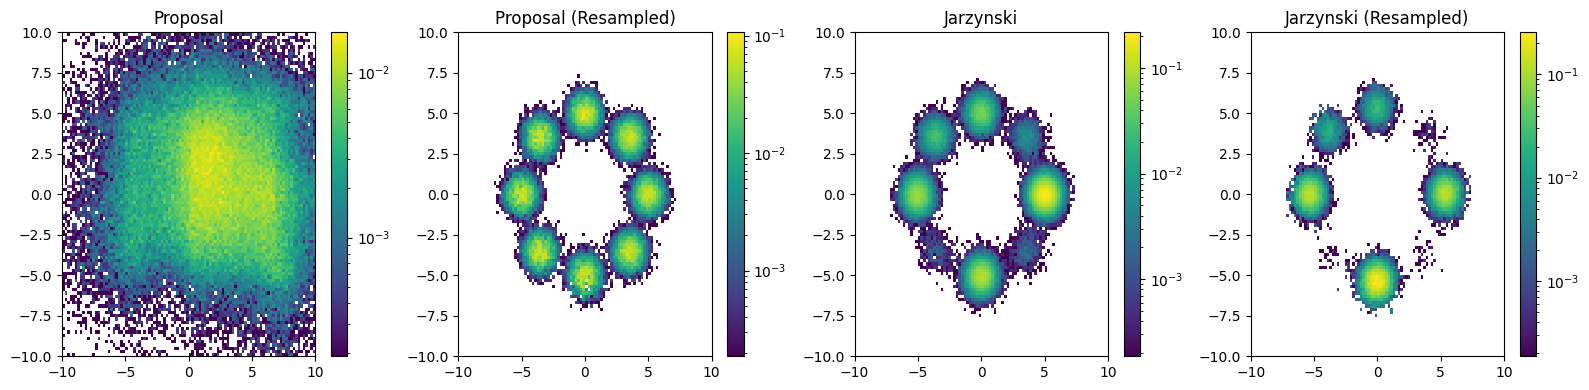

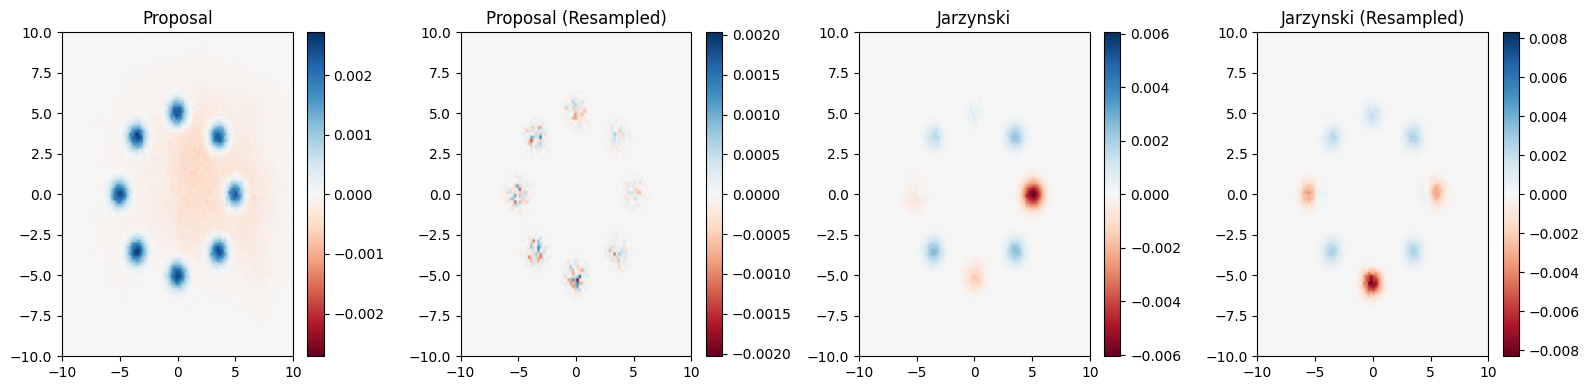

In [29]:
jarzynski_resamples = jarzynski_samples[torch.multinomial(jarzynski_weights, num_samples, replacement=True)]

# Histogram Plot
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4), tight_layout=True)
histogram_plot(ax1, samples, "Proposal")
histogram_plot(ax2, resamples, "Proposal (Resampled)")
histogram_plot(ax3, jarzynski_samples, "Jarzynski")
histogram_plot(ax4, jarzynski_resamples, "Jarzynski (Resampled)")

# Histogram Difference Plot
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(16, 4), tight_layout=True)
true_samples = eight_normal_sample(num_samples).numpy()
histogram_diff(ax1, true_samples, samples, "Proposal")
histogram_diff(ax2, true_samples, resamples, "Proposal (Resampled)")
histogram_diff(ax3, true_samples, jarzynski_samples, "Jarzynski")
histogram_diff(ax4, true_samples, jarzynski_resamples, "Jarzynski (Resampled)")

Text(0.5, 1.0, 'Histogram of $A$ (Jarzynski log weights)')

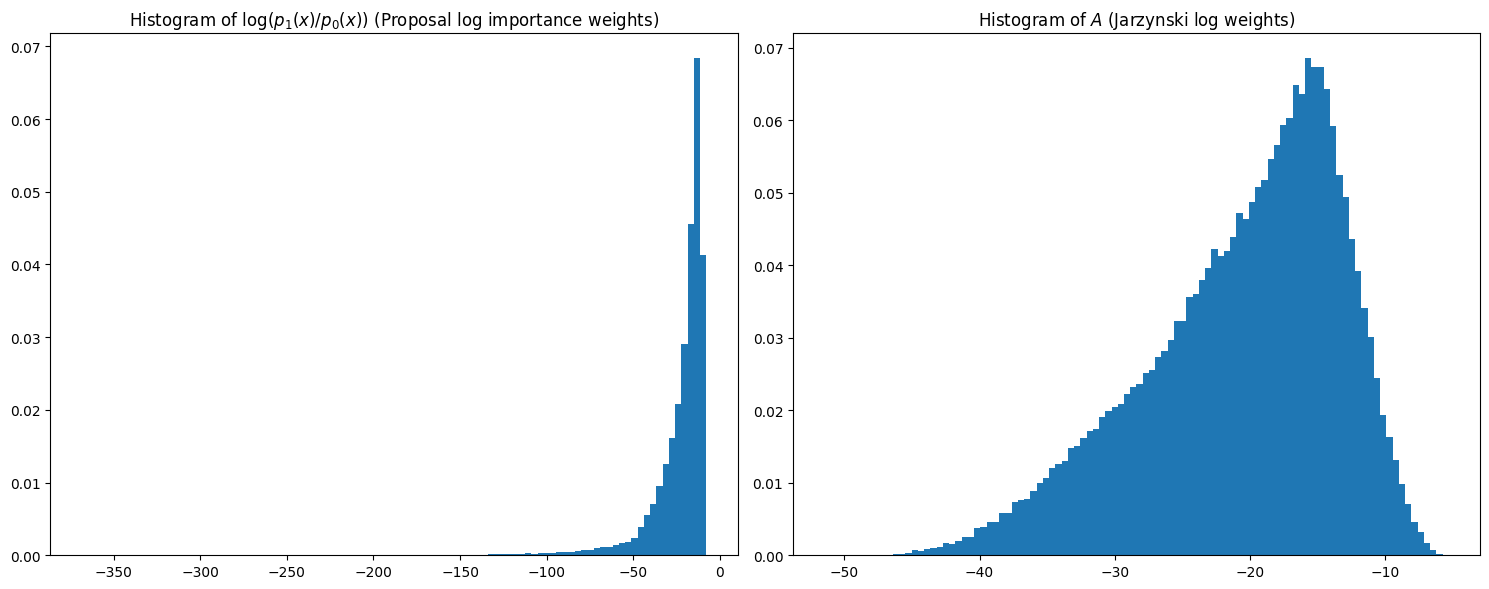

In [20]:
## Scatter Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6), tight_layout=True)
ax1.hist(np.log(importance_weights).numpy(), bins=100, density=True)
ax1.set_title(r"Histogram of $\log (p_1(x)/p_0(x))$ (Proposal log importance weights)")
ax2.hist(np.log(jarzynski_weights.numpy()), bins=100, density=True)
ax2.set_title(r"Histogram of $A$ (Jarzynski log weights)")

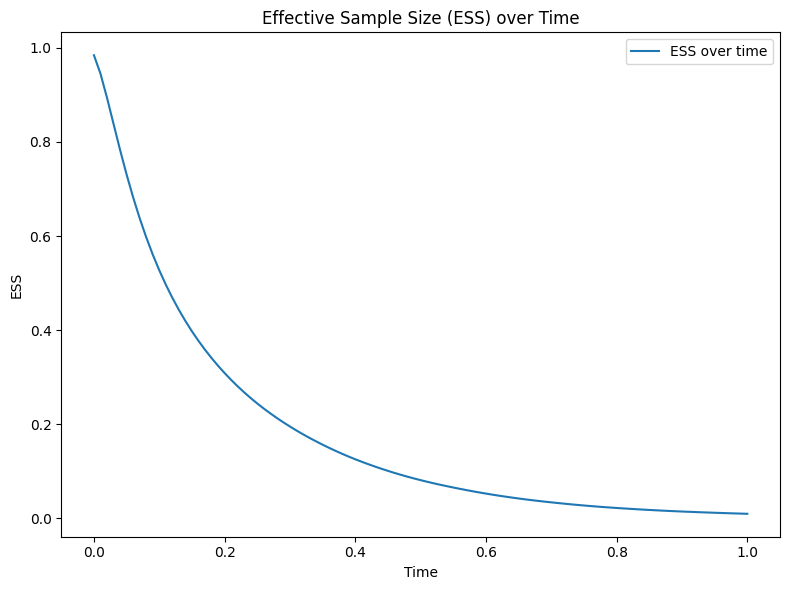

In [13]:
ESS_values = np.array(ESS_list)
time_values = timesteps.numpy()

fig, ax = plt.subplots(1, 1, figsize=(8, 6), tight_layout=True)
ax.plot(time_values, ESS_values, label='ESS over time')
ax.set_xlabel('Time')
ax.set_ylabel('ESS')
ax.set_title('Effective Sample Size (ESS) over Time')
ax.legend()
plt.show()

## Sanity checking Jarzynski

A: Mean = -10.261059761047363, Min = -28.515933990478516, Max = 12.386882781982422
e^A: Mean = 4.450862407684326, Min = 4.127501292139346e-13, Max = 239637.53125


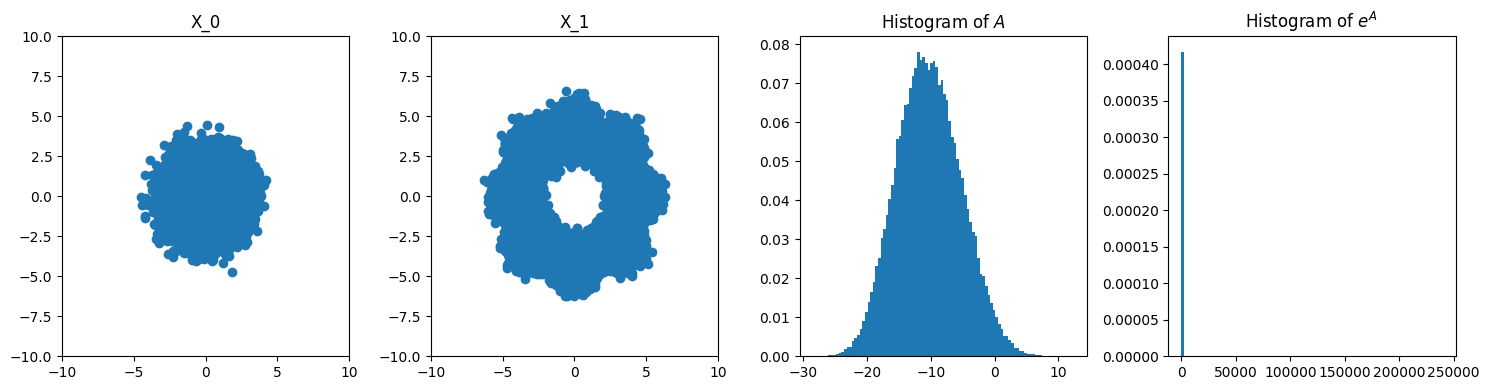

In [27]:
from torch.distributions.multivariate_normal import MultivariateNormal

N = 100000
eps = 1.0
num_timesteps = 100

prior = MultivariateNormal(torch.zeros(2), torch.eye(2), validate_args=False)
prior_energy = lambda x: -prior.log_prob(x).flatten()
target_energy = lambda x: -eight_normal_log_prob(x).flatten() - math.log(2)

def linear_energy_interpolation(x, t):
    return ((1 - t) * prior_energy(x) + t * target_energy(x)).squeeze()

energy_grad_x_fn = torch.vmap(torch.func.grad(linear_energy_interpolation), in_dims=(0, None))
energy_partial_t_fn = torch.vmap(torch.func.grad(linear_energy_interpolation, argnums=1), in_dims=(0, None))

X_0 = prior.sample((N,))
X = X_0
A = torch.zeros(N)
timesteps = torch.linspace(0, 1, num_timesteps + 1)
dt = 1 / num_timesteps

with torch.no_grad():

    for t in timesteps:

        dX_t = - eps * energy_grad_x_fn(X, t) * dt + math.sqrt(2 * eps * dt) * torch.randn_like(X)
        dA_t = - energy_partial_t_fn(X, t) * dt

        X = X + dX_t
        A = A + dA_t

## Scatter Plot
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 4), tight_layout=True)
scatter_plot(ax1, X_0, "X_0")
scatter_plot(ax2, X, f"X_1")

## Histograms
ax3.hist(A.numpy(), bins=100, density=True)
ax3.set_title(r"Histogram of $A$")
ax4.hist(np.exp(A.numpy()), bins=100, density=True)
ax4.set_title(r"Histogram of $e^A$")

print(f"A: Mean = {A.mean().item()}, Min = {A.min().item()}, Max = {A.max().item()}")
print(f"e^A: Mean = {np.exp(A.numpy()).mean()}, Min = {np.exp(A.numpy()).min()}, Max = {np.exp(A.numpy()).max()}")